In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data")).resolve()

df_per_subject = pd.read_csv(output_dir / "datasets_tidy_per_subject.csv")
df_total = pd.read_csv(output_dir / "datasets_tidy_total.csv")

pivot_per_subject = df_per_subject.pivot_table(index="dataset", columns="dotpath", values="value", aggfunc="first")
pivot_total = df_total.pivot_table(index="dataset", columns="dotpath", values="value", aggfunc="first")
datasets_list = df_per_subject["dataset"].unique().tolist()

print(f"Loaded {len(datasets_list)} dataset(s)")

Loaded 4 dataset(s)


In [2]:
import sys
sys.path.insert(0, str(Path(__file__).resolve().parents[1])) if "__file__" in dir() else sys.path.insert(0, "../")
from analysis.visualisation import make_bubble_chart, make_legend

# Column groups: (group_name, color, [(label, dotpath, unit), ...])
# unit 'h'     = hours
# unit '#img'  = image count
# unit '#cond' = condition count
COLUMN_GROUPS_PER_SUBJECT = [
    ("Neuroimaging", "#4472C4", [
        ("fMRI",  "neuroimaging.fmri.per_subject_h",  "h"),
        ("EEG",   "neuroimaging.eeg.per_subject_h",   "h"),
        ("MEG",   "neuroimaging.meg.per_subject_h",   "h"),
        ("iEEG",  "neuroimaging.ieeg.per_subject_h",  "h"),
    ]),
    ("Stimuli", "#538135", [
        ("Images", "naturalistic_stimuli.images.per_subject_unique",           "#img"),
        ("Video",  "naturalistic_stimuli.video.per_subject_unique",            "h"),
        ("Audio",  "naturalistic_stimuli.audio.per_subject_unique",            "h"),
        ("Speech", "naturalistic_stimuli.speech_listening.per_subject_unique", "h"),
        ("Text",   "naturalistic_stimuli.text_reading.per_subject_unique",     "h"),
        ("Rest",   "naturalistic_stimuli.resting_state.per_subject_unique",    "h"),
    ]),
    ("Responses", "#C55A11", [
        ("Tasks", "responses.controlled_tasks.per_subject_unique", "#cond"),
        ("Games", "responses.game_actions.per_subject_unique",     "h"),
    ]),
    ("Physiology", "#7030A0", [
        ("ECG",   "physiology.ecg.per_subject_h",            "h"),
        ("Resp.", "physiology.respiration.per_subject_h",    "h"),
        ("PPG",   "physiology.plethysmograph.per_subject_h", "h"),
        ("EDA",   "physiology.eda.per_subject_h",            "h"),
        ("Eye",   "physiology.eye_tracking.per_subject_h",   "h"),
    ]),
]

COLUMN_GROUPS_TOTAL = [
    ("Neuroimaging", "#4472C4", [
        ("fMRI",  "neuroimaging.fmri.total_h",  "h"),
        ("EEG",   "neuroimaging.eeg.total_h",   "h"),
        ("MEG",   "neuroimaging.meg.total_h",   "h"),
        ("iEEG",  "neuroimaging.ieeg.total_h",  "h"),
    ]),
    ("Stimuli", "#538135", [
        ("Images", "naturalistic_stimuli.images.total_unique",           "#img"),
        ("Video",  "naturalistic_stimuli.video.total_unique",            "h"),
        ("Audio",  "naturalistic_stimuli.audio.total_unique",            "h"),
        ("Speech", "naturalistic_stimuli.speech_listening.total_unique", "h"),
        ("Text",   "naturalistic_stimuli.text_reading.total_unique",     "h"),
        ("Rest",   "naturalistic_stimuli.resting_state.total_unique",    "h"),
    ]),
    ("Responses", "#C55A11", [
        ("Tasks", "responses.controlled_tasks.total_unique", "#cond"),
        ("Games", "responses.game_actions.total_unique",     "h"),
    ]),
    ("Physiology", "#7030A0", [
        ("ECG",   "physiology.ecg.total_h",            "h"),
        ("Resp.", "physiology.respiration.total_h",    "h"),
        ("PPG",   "physiology.plethysmograph.total_h", "h"),
        ("EDA",   "physiology.eda.total_h",            "h"),
        ("Eye",   "physiology.eye_tracking.total_h",   "h"),
    ]),
]

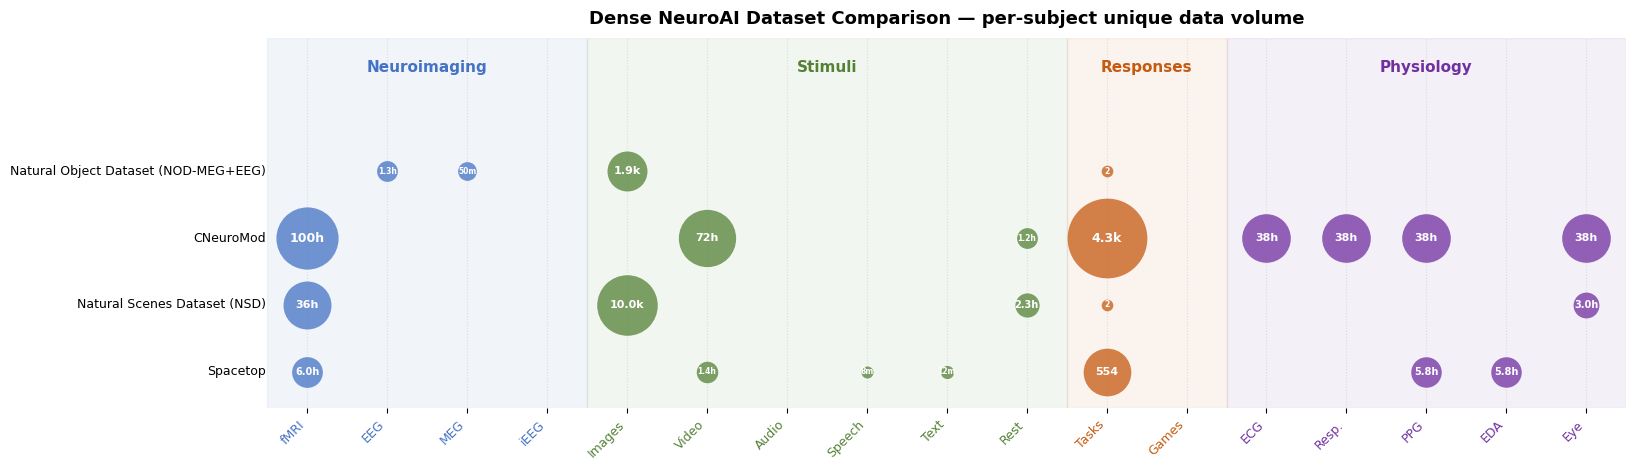

Saved dataset_comparison_per_subject.png


In [3]:
make_bubble_chart(
    COLUMN_GROUPS_PER_SUBJECT,
    pivot_per_subject,
    datasets_list,
    "Dense NeuroAI Dataset Comparison — per-subject unique data volume",
    output_dir / "dataset_comparison_per_subject.png",
)

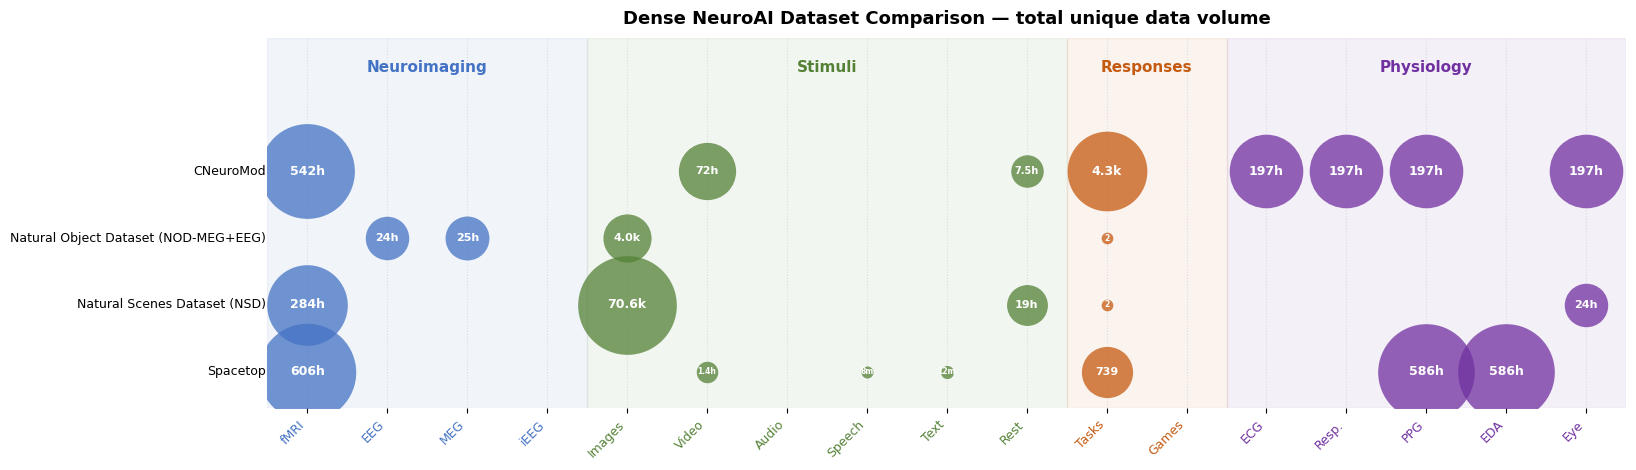

Saved dataset_comparison_total.png


In [4]:
make_bubble_chart(
    COLUMN_GROUPS_TOTAL,
    pivot_total,
    datasets_list,
    "Dense NeuroAI Dataset Comparison — total unique data volume",
    output_dir / "dataset_comparison_total.png",
)

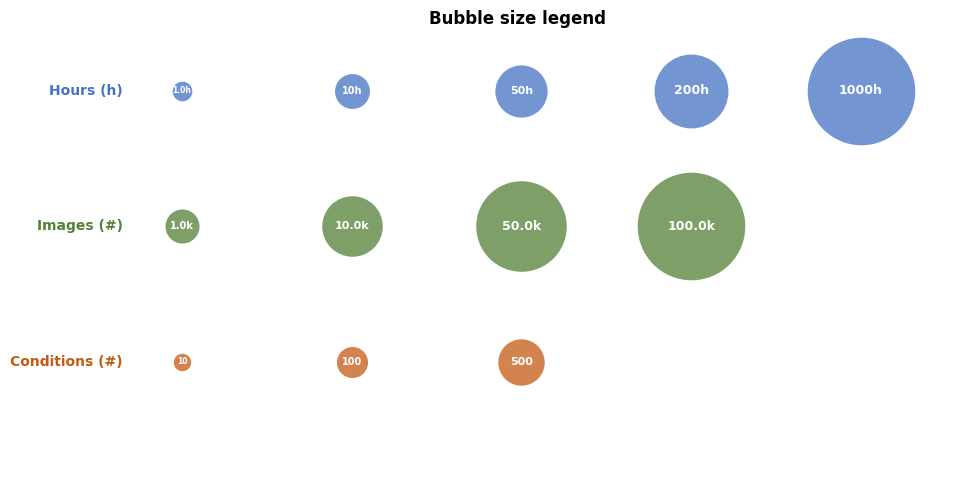

Saved dataset_comparison_legend.png


In [5]:
make_legend(output_dir / "dataset_comparison_legend.png")

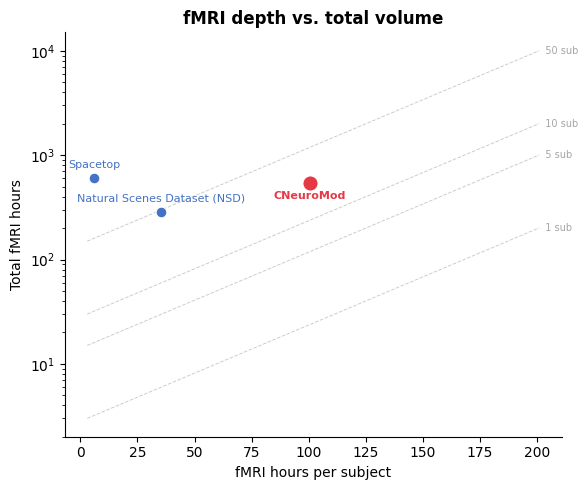

Saved dataset_fmri_scatter.png


In [6]:
from analysis.visualisation import make_fmri_scatter

make_fmri_scatter(
    pivot_per_subject,
    pivot_total,
    datasets_list,
    output_dir / "dataset_fmri_scatter.png",
)